<a href="https://colab.research.google.com/github/SindhaAshish/Super-Store-Sales/blob/main/Superstore_Sales_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Super Store Sales Prediction

##1. Data Loading & Preparation

In [70]:
#let's import important libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import google.colab as colab
from google.colab import drive
#drive.mount('/content/drive')
import google.colab.files as files
from google.colab import files
uploaded = files.upload()

Saving superstoresales_train.csv to superstoresales_train (3).csv


In [71]:
#from google.colab import drive
#drive.mount('/content/drive')

In [72]:
df = pd.read_csv('superstoresales_train.csv')

In [73]:
df.columns = df.columns.str.lower().str.replace(' ','_')

In [74]:
#df['Sales'] = df['Sales'].astype('float32')
#df['estimated_profit'] = df['Sales'] * 0.15
df['estimated_profit'] = df['sales'].astype('float32') * 0.15
#df['estimated_profit'] = pd.eval("df['Sales'] * 0.15") not working
#df['estimated_profit'] = (df['Sales'] * 0.15)

In [75]:
df.isnull().head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,state,postal_code,region,product_id,category,sub-category,product_name,sales,estimated_profit
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [76]:
missing_values_count = df.isnull().sum()
display(missing_values_count)

,0
row_id,0
order_id,0
order_date,0
ship_date,0
ship_mode,0
customer_id,0
customer_name,0
segment,0
country,0
city,0


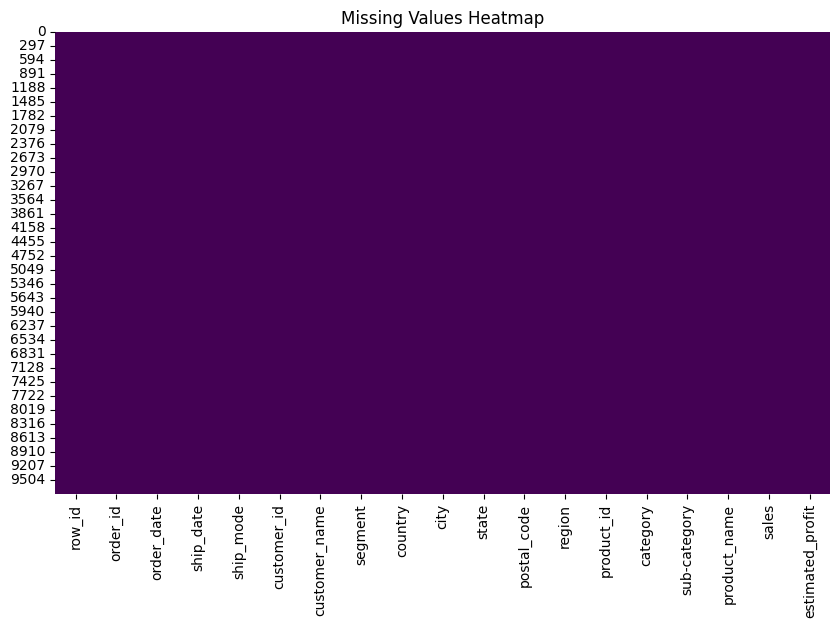

In [77]:
#Generating Heatmap with Missing Values
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(),cbar = False,cmap = 'viridis')
plt.title('Missing Values Heatmap')
plt.show()

In [78]:
df=df.drop_duplicates().head()

In [79]:
df=df.dropna().head()

In [80]:
df.describe()

,row_id,postal_code,sales,estimated_profit
count,5.000000,5.000000,5.000000,5.000000
mean,3.000000,48299.600000,397.694000,59.654102
std,1.581139,23771.741297,427.560006,64.134010
min,1.000000,33311.000000,14.620000,2.193000
25%,2.000000,33311.000000,22.370000,3.355500
50%,3.000000,42420.000000,261.960000,39.293999
75%,4.000000,42420.000000,731.940000,109.791008
max,5.000000,90036.000000,957.580000,143.637009


## 2. Exploratory Data Analysis

In [81]:
df['order_date'] = pd.to_datetime(df['order_date'])
df['ship_date'] = pd.to_datetime(df['ship_date'])
display(df[['order_date','ship_date']].head())

,order_date,ship_date
0,2017-11-08,2017-11-11
1,2017-11-08,2017-11-11
2,2017-06-12,2017-06-16
3,2016-10-11,2016-10-18
4,2016-10-11,2016-10-18


In [82]:
df['fastest_shiping_days'] = df['ship_date'] - df['order_date']
df['fastest_shiping_days'] = df['fastest_shiping_days'].dt.days
df.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,state,postal_code,region,product_id,category,sub-category,product_name,sales,estimated_profit,fastest_shiping_days
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,39.293999,3
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,109.791008,3
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2.193000,4
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.58,143.637009,7
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.37,3.355500,7


In [83]:
average_shipping_time = df['fastest_shiping_days'].mean()
print(f"Average shipping time: {average_shipping_time:.2f} days")

Average shipping time: 4.80 days


In [84]:
df.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,state,postal_code,region,product_id,category,sub-category,product_name,sales,estimated_profit,fastest_shiping_days
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,39.293999,3
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,109.791008,3
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2.193000,4
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.58,143.637009,7
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.37,3.355500,7


In [85]:
#Fastest Shipping Days by Shipping Modes
average_shipping_time_by_mode = df.groupby('ship_mode')['fastest_shiping_days'].mean()
display(average_shipping_time_by_mode)

,fastest_shiping_days
ship_mode,
Second Class,3.333333
Standard Class,7.000000


In [86]:
average_shipping_time_by_region = df.groupby('region')['fastest_shiping_days'].mean()
display(average_shipping_time_by_region)

,fastest_shiping_days
region,
South,5.0
West,4.0


In [87]:
average_sales = df['sales'].mean()
#display(average_sales)
print(f"Average Sales: {average_sales:.2f}")

Average Sales: 397.69


In [88]:
average_sales_by_region = df.groupby('region')['sales'].mean()
display(average_sales_by_region)

,sales
region,
South,493.4625
West,14.6200


In [89]:
average_sales_by_category_sub_category = df.groupby(['category','sub-category'])['sales'].mean()
display(average_sales_by_category_sub_category)

category         sub-category
Furniture        Bookcases       261.96
                 Chairs          731.94
                 Tables          957.58
Office Supplies  Labels           14.62
                 Storage          22.37
Name: sales, dtype: float64

In [90]:
estimated_profit_by_region = df.groupby('region')['estimated_profit'].sum()
display(estimated_profit_by_region)

,estimated_profit
region,
South,296.077515
West,2.193000


In [91]:
estimated_profit_by_category = df.groupby('category')['estimated_profit'].sum()
display(estimated_profit_by_category)

,estimated_profit
category,
Furniture,292.722015
Office Supplies,5.548500


In [92]:
estimated_profit_by_sub_category = df.groupby('sub-category')['estimated_profit'].sum()
display(estimated_profit_by_sub_category)

,estimated_profit
sub-category,
Bookcases,39.293999
Chairs,109.791008
Labels,2.193000
Storage,3.355500
Tables,143.637009


In [93]:
average_estimated_profit = df['estimated_profit'].mean()
display(average_estimated_profit)

np.float32(59.654102)

##3. Data Visualisation with Matplotlib and Seaborn

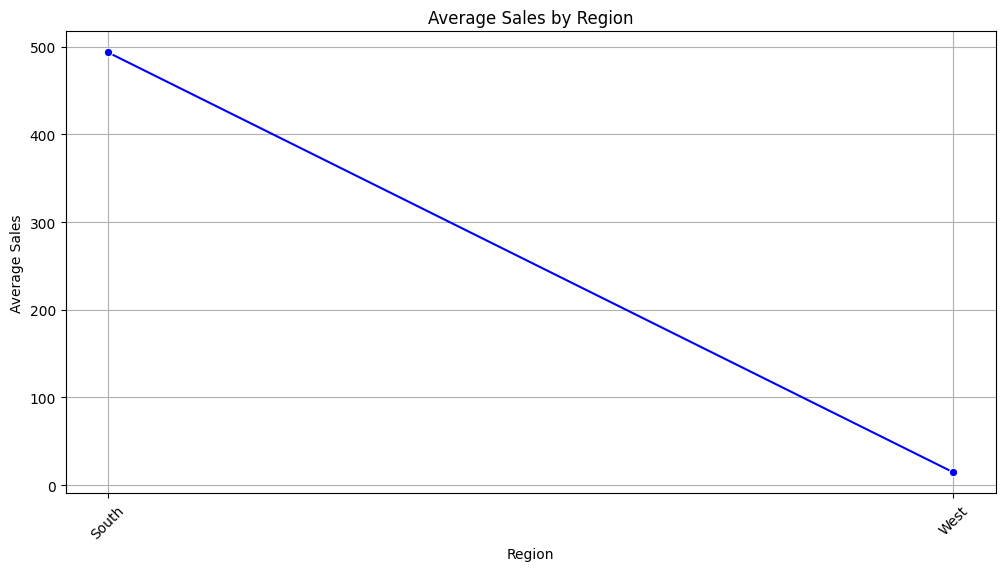

In [94]:
plt.figure(figsize=(12,6))
sns.lineplot(x=average_sales_by_region.index,y=average_sales_by_region.values,marker='o',color='blue')
plt.title('Average Sales by Region')
plt.xlabel('Region')
plt.ylabel('Average Sales')
plt.xticks(rotation=45)
plt.grid()
plt.show()

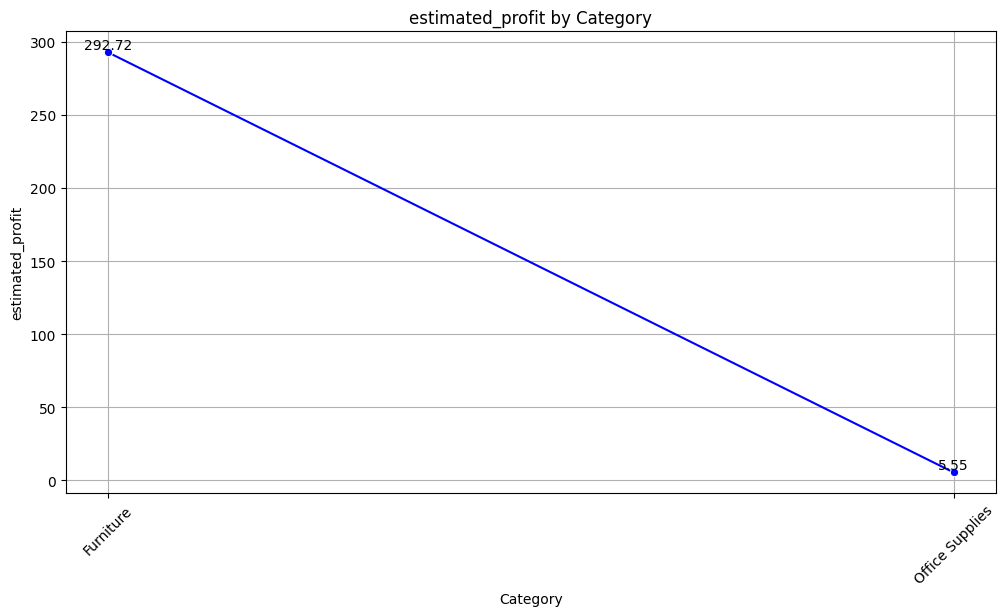

In [95]:
plt.figure(figsize=(12,6))
sns.lineplot(x=estimated_profit_by_category.index,y=estimated_profit_by_category.values,marker='o',color='blue')
plt.title('estimated_profit by Category')
plt.xlabel('Category')
plt.ylabel('estimated_profit')
plt.xticks(rotation=45)
plt.grid(True)
#Add Values Above Data point
for x,y in zip(estimated_profit_by_category.index,estimated_profit_by_category.values):
  plt.text(x,y,f'{y:.2f}',ha='center',va='bottom')

plt.show()

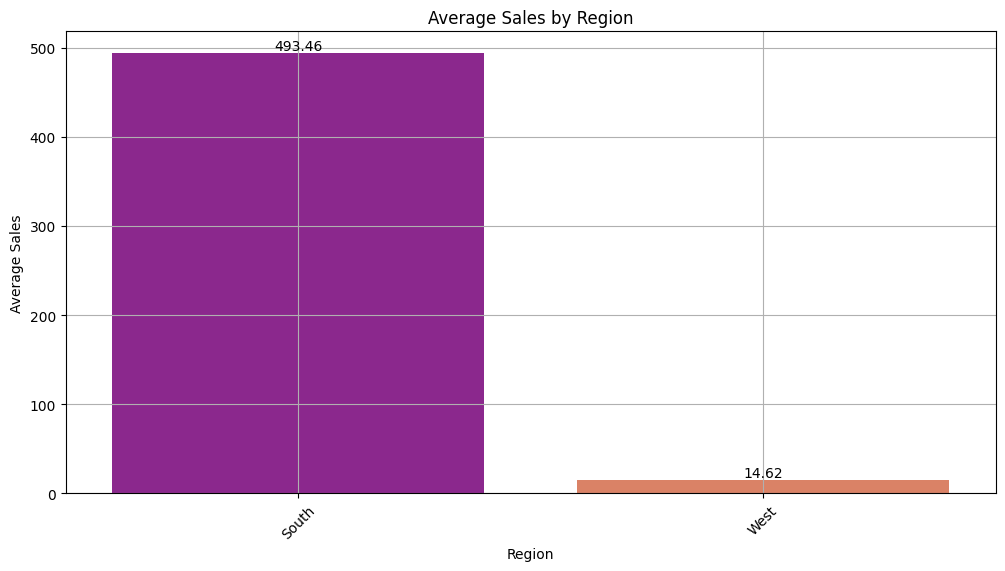

In [96]:
plt.figure(figsize=(12,6))
ax = sns.barplot(x=average_sales_by_region.index,y=average_sales_by_region.values,palette='plasma', hue=average_sales_by_region.index, legend=False)
plt.title('Average Sales by Region')
plt.xlabel('Region')
plt.ylabel('Average Sales')
plt.xticks(rotation=45)
plt.grid()

# Add values above bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='top', xytext=(0, 10), textcoords='offset points')

plt.show()

/tmp/ipykernel_3716/2900880222.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=average_shipping_time_by_mode.index,y=average_shipping_time_by_mode.values,palette='viridis')


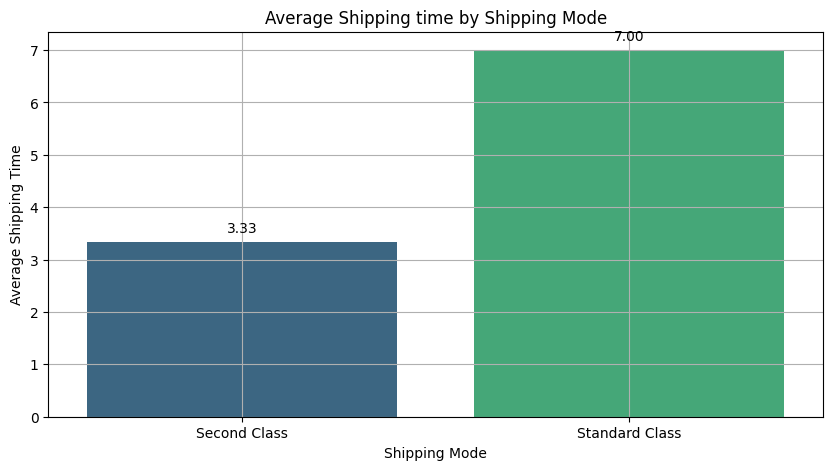

In [97]:
plt.figure(figsize=(10,5))
ax = sns.barplot(x=average_shipping_time_by_mode.index,y=average_shipping_time_by_mode.values,palette='viridis')
plt.title('Average Shipping time by Shipping Mode')
plt.xlabel('Shipping Mode')
plt.ylabel('Average Shipping Time')
plt.grid()

# Add values above bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')

plt.show()

### estimated_profit by Sub-Category
This bar chart will show the total estimated_profit generated by each sub-category, allowing for a detailed comparison of estimated_profitability across product types.

/tmp/ipykernel_3716/1235552639.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=estimated_profit_by_sub_category.index,y=estimated_profit_by_sub_category.values,palette='viridis')


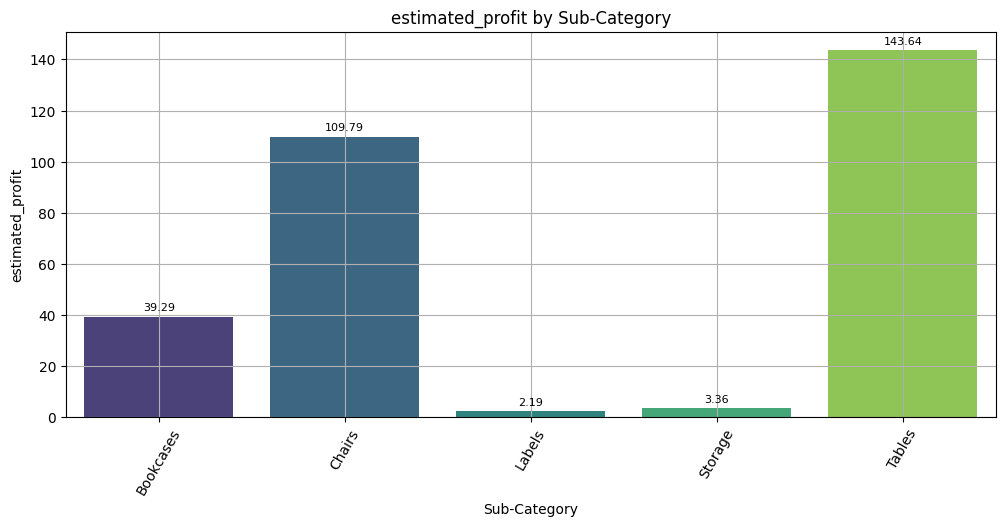

In [98]:
plt.figure(figsize=(12,5))
ax = sns.barplot(x=estimated_profit_by_sub_category.index,y=estimated_profit_by_sub_category.values,palette='viridis')
plt.title('estimated_profit by Sub-Category')
plt.xlabel('Sub-Category')
plt.ylabel('estimated_profit')
plt.grid()
plt.xticks(rotation=60)

#Add Data Points on Bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}',(p.get_x()+p.get_width()/2.,p.get_height()),
    ha='center',va='top',xytext=(0,10),textcoords='offset points',fontsize=8)

#plt.tight_layout()
plt.show()

### Distribution of Sales
A histogram will help understand the frequency distribution of `sales` values, showing if sales are concentrated in certain ranges or are widely spread.

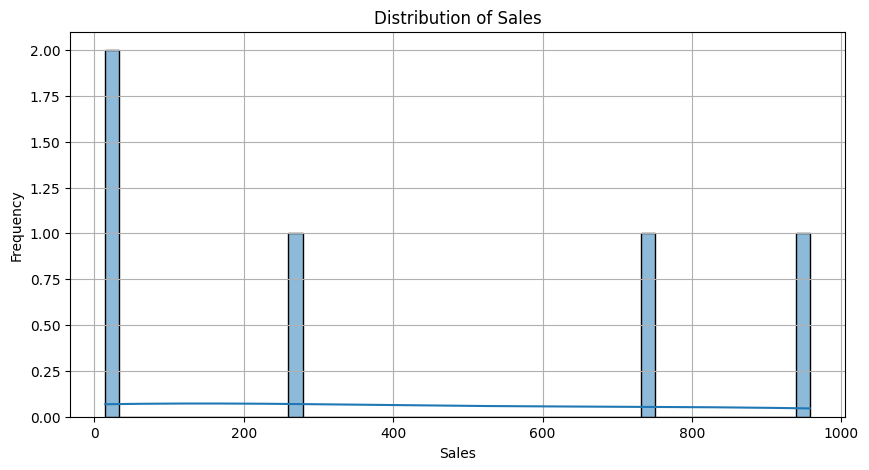

In [99]:
plt.figure(figsize=(10,5))
sns.histplot(df['sales'],bins=50,kde=True)
plt.title('Distribution of Sales')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

### Monthly Sales Trend
By extracting the month and year from the `order_date`, we can analyze how sales have changed over time, revealing seasonality or growth trends.

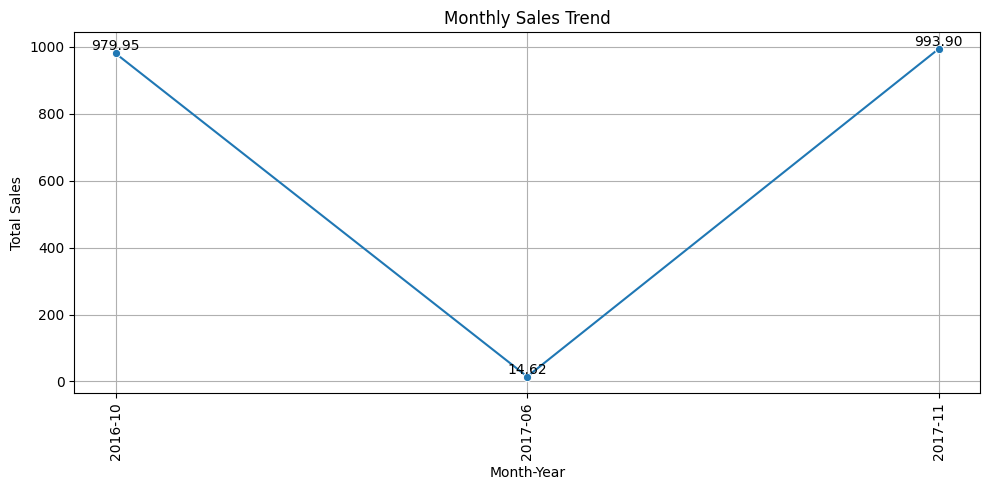

In [100]:
df['order_year_month']=df['order_date'].dt.to_period('M')
monthly_sales = df.groupby('order_year_month')['sales'].sum().reset_index()
monthly_sales['order_year_month']=monthly_sales['order_year_month'].astype(str)

plt.figure(figsize=(10,5))
sns.lineplot(x='order_year_month',y='sales',data=monthly_sales,marker='o')
plt.title('Monthly Sales Trend')
plt.xlabel('Month-Year')
plt.ylabel('Total Sales')
plt.xticks(rotation=90)
plt.grid(True)

for x,y in zip(monthly_sales['order_year_month'],monthly_sales['sales']):
  plt.text(x,y,f'{y:.2f}',ha='center',va='bottom')

plt.tight_layout()
plt.show()

### Total Sales by Customer Segment
This bar chart illustrates the total sales attributed to each customer segment, providing insights into which segments contribute most to the overall revenue.

/tmp/ipykernel_3716/375505432.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='segment',y='sales',data=total_sales_by_segment,palette='viridis')


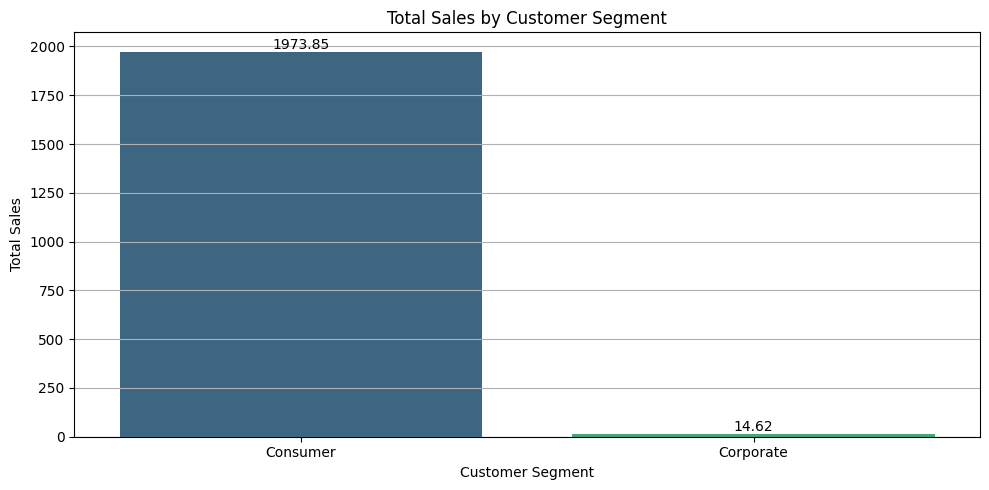

In [101]:
total_sales_by_segment = df.groupby('segment')['sales'].sum().reset_index()

plt.figure(figsize=(10,5))
ax = sns.barplot(x='segment',y='sales',data=total_sales_by_segment,palette='viridis')
plt.title('Total Sales by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Total Sales')
plt.grid(axis='y')

# Add values above bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

### Top 10 Products by Total Sales
This bar chart highlights the top 10 products that have generated the highest total sales, offering insights into best-selling items.

/tmp/ipykernel_3716/3410659340.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='sales',y='product_name',data=top_10_products,palette='viridis')


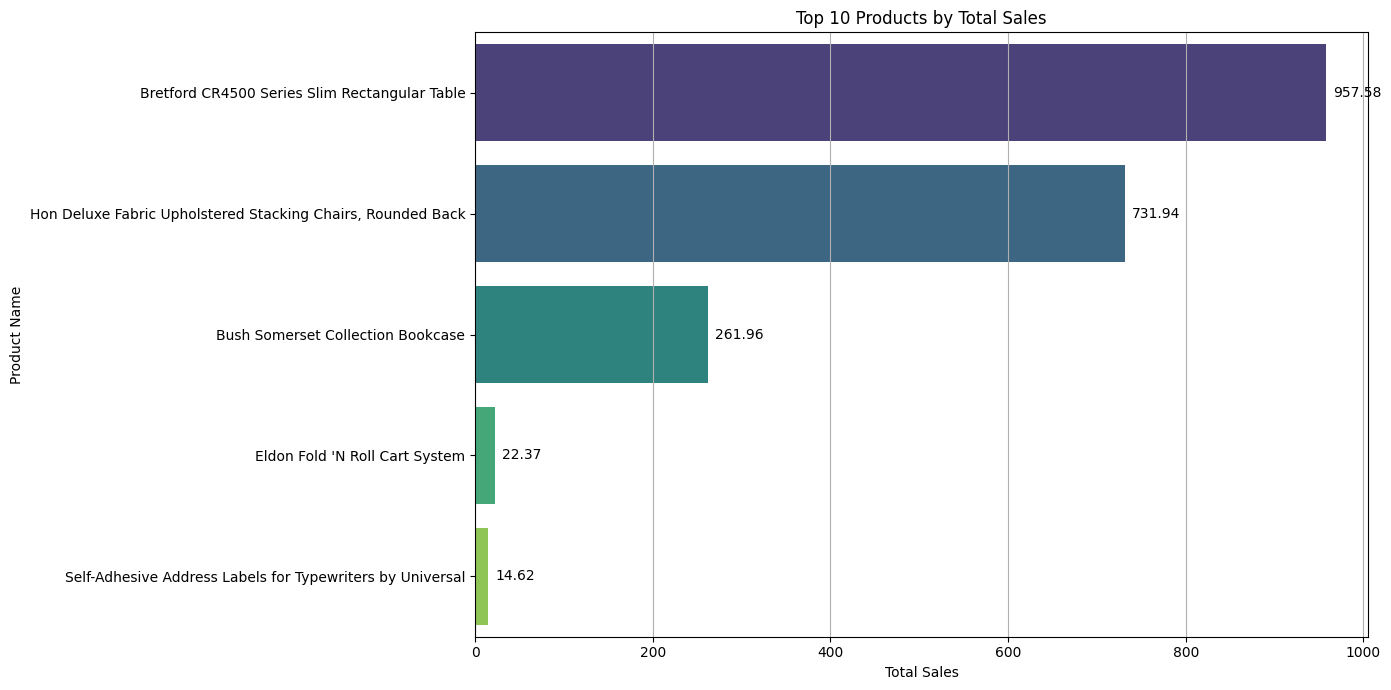

In [102]:
top_10_products = df.groupby('product_name')['sales'].sum().nlargest(10).reset_index()

plt.figure(figsize=(14,7))
ax = sns.barplot(x='sales',y='product_name',data=top_10_products,palette='viridis')
plt.title('Top 10 Products by Total Sales')
plt.xlabel('Total Sales')
plt.ylabel('Product Name')
plt.grid(axis='x')

#Adding data labels
for p in ax.patches:
    ax.annotate(f'{p.get_width():.2f}', (p.get_width(),p.get_y() + p.get_height()/2.),
                ha = 'left', va = 'center',xytext=(5,0),textcoords='offset points')
plt.tight_layout()
plt.show()

### Top 5 Customers by Total Sales
This chart identifies the five customers who have generated the highest total sales, indicating key revenue drivers.

/tmp/ipykernel_3716/3593381401.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='sales',y='customer_name',data=top_5_customers,palette='plasma')


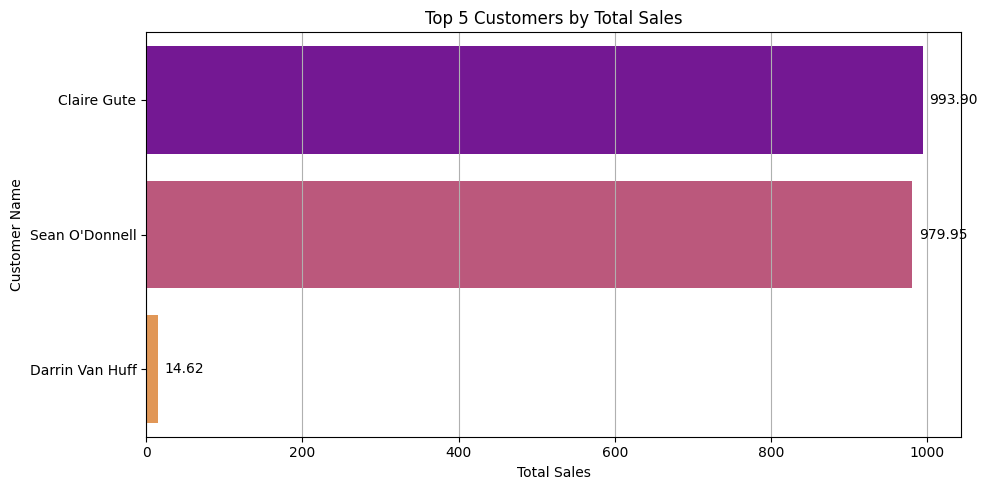

In [103]:
top_5_customers = df.groupby('customer_name')['sales'].sum().nlargest(5).reset_index()

plt.figure(figsize=(10,5))
ax = sns.barplot(x='sales',y='customer_name',data=top_5_customers,palette='plasma')
plt.title('Top 5 Customers by Total Sales')
plt.xlabel('Total Sales')
plt.ylabel('Customer Name')
plt.grid(axis='x')

#Add Data labels
for p in ax.patches:
    ax.annotate(f'{p.get_width():.2f}',(p.get_width(),p.get_y() + p.get_height()/2.),
                ha = 'left', va = 'center',xytext=(5,0),textcoords='offset points')
plt.tight_layout()
plt.show()

### Correlation between Discounts and Sales
Calculating the Pearson correlation coefficient between 'discount' and 'sales' will help us understand if there is a linear relationship between the two, i.e., whether increasing discounts tend to lead to higher or lower sales.

In [104]:
if 'discount' in df.columns and 'sales' in df.columns:
  correlation = df['discount'].corr(df['sales'])
  print(f"Pearson Correlation Coefficient: {correlation:.2f}")
else:
  print("One or both of 'discount' and 'sales' columns are missing in the DataFrame")

One or both of 'discount' and 'sales' columns are missing in the DataFrame
